In [1]:
import pandas as pd

## Clean "Barbell"

In [2]:
trial_df = pd.read_csv("/home/bily/python/activity_tracker/data/Recovery workout log - barbell weights.csv")

In [3]:
trial_df.head()

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?
0,25.8.15,calf raise machine,10,3,0,0.0,60.0,60/40 2 legged,yes
1,25.8.15,heel raise squat bar,10,3,0,0.0,60.0,NaN,yes
2,25.8.15,1 leg extension,10,3,45,20.0,60.0,NaN,yes
3,25.8.15,1 leg curl,10,3,30,14.0,60.0,NaN,yes
4,25.8.22,calf raise machine,10,3,0,0.0,60.0,70/30 2 legged,yes


In [4]:
trial_df.loc[trial_df['exercise'].str.contains("dead"), 'mass (lbs)'].max()

np.int64(253)

In [5]:
index = trial_df[trial_df['date'].str.count('\.') == 1].index
index

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/tmp/ipykernel_74363/1560749460.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  index = trial_df[trial_df['date'].str.count('\.') == 1].index


Index([167, 170, 171, 172], dtype='int64')

In [6]:
a = "24.03.24"
print(a.replace(".", ''))

240324


In [7]:
def fix_date(value):
    fresh_start = value.replace(".", "").strip().replace(" ", "")
    if len(fresh_start) == 6:
        new_value = fresh_start[0:2] + "." + fresh_start[2:4] + "." + fresh_start[4:6]
    elif len(fresh_start) == 5:
        if fresh_start[0:3] == "258":
            new_value = fresh_start[0:2] + ".0" + fresh_start[2:3] + "." + fresh_start[3:5]
    else:
        new_value = "bugger"
    return new_value

trial_df['date'] = trial_df['date'].apply(fix_date)

In [8]:
trial_df.head()

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?
0,25.08.15,calf raise machine,10,3,0,0.0,60.0,60/40 2 legged,yes
1,25.08.15,heel raise squat bar,10,3,0,0.0,60.0,NaN,yes
2,25.08.15,1 leg extension,10,3,45,20.0,60.0,NaN,yes
3,25.08.15,1 leg curl,10,3,30,14.0,60.0,NaN,yes
4,25.08.22,calf raise machine,10,3,0,0.0,60.0,70/30 2 legged,yes


In [9]:
trial_df['date'] = pd.to_datetime(trial_df['date'], format='%y.%m.%d')

In [10]:
trial_df.head()

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?
0,2025-08-15,calf raise machine,10,3,0,0.0,60.0,60/40 2 legged,yes
1,2025-08-15,heel raise squat bar,10,3,0,0.0,60.0,NaN,yes
2,2025-08-15,1 leg extension,10,3,45,20.0,60.0,NaN,yes
3,2025-08-15,1 leg curl,10,3,30,14.0,60.0,NaN,yes
4,2025-08-22,calf raise machine,10,3,0,0.0,60.0,70/30 2 legged,yes


Let's try to find a more holistic way of fixing the date

I bet regex will work pretty well 

I am not sure I will be able to capture all scenarios like if I forgot 2 "."s - there would have to be some assumptions made

In [11]:
temp_df = pd.read_csv("/home/bily/python/activity_tracker/data/Recovery workout log - barbell weights.csv")
regex_pattern = r'(\d{2})[.\s]?(\d{1,2})[.\s]?(\d{1,2})'
extracted_date = temp_df['date'].str.extract(regex_pattern)

In [12]:
extracted_date

,0,1,2
0,25,8,15
1,25,8,15
2,25,8,15
3,25,8,15
4,25,8,22
...,...,...,...
246,26,03,20
247,26,03,20
248,26,03,20
249,26,03,20


In [13]:
extracted_date.columns = ['year', 'month', 'day']
temp_df['clean_date'] = ("20" + 
                         extracted_date['year'] +
                           "-" + extracted_date['month'].str.zfill(2) + 
                           "-" + extracted_date['day'].str.zfill(2))

temp_df

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?,clean_date
0,25.8.15,calf raise machine,10,3,0,0.0,60.0,60/40 2 legged,yes,2025-08-15
1,25.8.15,heel raise squat bar,10,3,0,0.0,60.0,NaN,yes,2025-08-15
2,25.8.15,1 leg extension,10,3,45,20.0,60.0,NaN,yes,2025-08-15
3,25.8.15,1 leg curl,10,3,30,14.0,60.0,NaN,yes,2025-08-15
4,25.8.22,calf raise machine,10,3,0,0.0,60.0,70/30 2 legged,yes,2025-08-22
...,...,...,...,...,...,...,...,...,...,...
246,26.03.20,calf raise machine,12,3,15,NaN,60.0,NaN,NaN,2026-03-20
247,26.03.20,bench press,5,1,45,NaN,NaN,NaN,NaN,2026-03-20
248,26.03.20,bench press,5,1,95,NaN,NaN,NaN,NaN,2026-03-20
249,26.03.20,bench press,5,2,115,NaN,NaN,NaN,NaN,2026-03-20


In [14]:
temp_df['clean_date'] = pd.to_datetime(temp_df['clean_date'])

In [15]:
# I had an issue where a date was missing the second "." so I updated regex to look for "." or " "
temp_df.loc[temp_df['clean_date'] == '2026-01-20']

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?,clean_date
167,26.01 20,squat,8,1,45,20.0,60.0,NaN,NaN,2026-01-20
168,26.01.20,squat,5,2,95,43.0,60.0,NaN,NaN,2026-01-20
169,26.01.20,squat,5,2,135,61.0,120.0,NaN,NaN,2026-01-20
170,26.01 20,squat,5,1,145,66.0,NaN,NaN,NaN,2026-01-20
171,26.01 20,deadlift,5,1,65,29.0,60.0,NaN,NaN,2026-01-20
172,26.01 20,deadlift,5,1,135,61.0,90.0,NaN,NaN,2026-01-20


In [16]:
extracted_date.iloc[167]

year     26
month    01
day      20
Name: 167, dtype: str

In [17]:
outliers = temp_df[temp_df['clean_date'].isna()]
print(outliers)

Empty DataFrame
Columns: [date, exercise, reps, set, mass (lbs), mass (kgs), rest, notes, to failure?, clean_date]
Index: []


I like this way better - I am not super comfortable with regex, but it is really useful - I would like to look into resources to practice and learn regex instead of desperately looking it up when I need it

In [18]:
temp_df.columns

Index(['date', 'exercise', 'reps', 'set', 'mass (lbs)', 'mass (kgs)', 'rest',
       'notes', 'to failure?', 'clean_date'],
      dtype='str')

In [19]:
temp_df['exercise'].value_counts().sort_index()


exercise
1 leg curl                 29
1 leg extension            21
1 leg extension             7
1 leg heel raise           23
1 leg side arm thing        1
1 leg squats               13
2 legged jumps              1
bench press                33
calf raise machine          9
deadlift                   32
deadlift                   25
heel raise squat bar        9
incline press               9
slant board heel raises     4
squat                      16
squat                      19
Name: count, dtype: int64

Looks like there are some stray " "s in these names

In [20]:
temp_df['exercise'].str.strip().value_counts().sort_index()

exercise
1 leg curl                 29
1 leg extension            28
1 leg heel raise           23
1 leg side arm thing        1
1 leg squats               13
2 legged jumps              1
bench press                33
calf raise machine          9
deadlift                   57
heel raise squat bar        9
incline press               9
slant board heel raises     4
squat                      35
Name: count, dtype: int64

In [21]:
temp_df['exercise'] = temp_df['exercise'].str.strip()

In [22]:
temp_df.dtypes

date                      str
exercise                  str
reps                    int64
set                     int64
mass (lbs)              int64
mass (kgs)            float64
rest                  float64
notes                     str
to failure?               str
clean_date     datetime64[us]
dtype: object

Very good. I think I am done cleaning that datasheet - pretty straight forward. It appears that reps, set, and masses are all numeric so nothing to really "fix" there. If there is an incorrect value we will just let that be for now

## Clean "Cardio"

In [23]:
cardio_df = pd.read_csv("/home/bily/python/activity_tracker/data/Recovery workout log - cardio.csv")

In [24]:
cardio_df

,Date,Activity,duration (min),distance km,notes
0,25.8.17,bike ride,NaN,40.23,NaN
1,25.8.18,swim,30.0,NaN,NaN
2,25.8.20,bike ride,NaN,20.10,NaN
3,25.8.21,swim,30.0,NaN,NaN
4,25.8.23,swim,30.0,NaN,NaN
5,25.8.25,swim,30.0,NaN,NaN
6,25.08.31,bike ride,NaN,20.10,NaN
7,25.09.01,swim,30.0,NaN,NaN
8,25.09.04,swim,45.0,NaN,NaN
9,25.10.27,swim,30.0,NaN,NaN


In [25]:
def fix_date(df):
    regex_pattern = r'(\d{2})[.\s]?(\d{1,2})[.\s]?(\d{1,2})'
    extracted_date = df['date'].str.extract(regex_pattern)
    extracted_date.columns = ['year', 'month', 'day']
    df['clean_date'] = ("20" + 
                        extracted_date['year'] +
                        "-" + extracted_date['month'].str.zfill(2) + 
                        "-" + extracted_date['day'].str.zfill(2))
    df['date'] = df['clean_date']
    df['date'] = pd.to_datetime(df['date'])
    return df

In [26]:
cardio_df = cardio_df.rename(columns={"Date": "date"})
cardio_df = fix_date(cardio_df)
cardio_df

,date,Activity,duration (min),distance km,notes,clean_date
0,2025-08-17,bike ride,NaN,40.23,NaN,2025-08-17
1,2025-08-18,swim,30.0,NaN,NaN,2025-08-18
2,2025-08-20,bike ride,NaN,20.10,NaN,2025-08-20
3,2025-08-21,swim,30.0,NaN,NaN,2025-08-21
4,2025-08-23,swim,30.0,NaN,NaN,2025-08-23
5,2025-08-25,swim,30.0,NaN,NaN,2025-08-25
6,2025-08-31,bike ride,NaN,20.10,NaN,2025-08-31
7,2025-09-01,swim,30.0,NaN,NaN,2025-09-01
8,2025-09-04,swim,45.0,NaN,NaN,2025-09-04
9,2025-10-27,swim,30.0,NaN,NaN,2025-10-27


In [27]:
cardio_df['Activity'].value_counts().sort_index()

Activity
bike          2
bike ride     4
run           1
swim         32
Name: count, dtype: int64

In [28]:
cardio_df['activity_broken'] = cardio_df['Activity'].str.split(" ")
cardio_df['Activity'] = cardio_df['activity_broken'].apply(lambda x: x[0])

In [29]:
cardio_df

,date,Activity,duration (min),distance km,notes,clean_date,activity_broken
0,2025-08-17,bike,NaN,40.23,NaN,2025-08-17,"[bike, ride]"
1,2025-08-18,swim,30.0,NaN,NaN,2025-08-18,[swim]
2,2025-08-20,bike,NaN,20.10,NaN,2025-08-20,"[bike, ride]"
3,2025-08-21,swim,30.0,NaN,NaN,2025-08-21,[swim]
4,2025-08-23,swim,30.0,NaN,NaN,2025-08-23,[swim]
5,2025-08-25,swim,30.0,NaN,NaN,2025-08-25,[swim]
6,2025-08-31,bike,NaN,20.10,NaN,2025-08-31,"[bike, ride]"
7,2025-09-01,swim,30.0,NaN,NaN,2025-09-01,[swim]
8,2025-09-04,swim,45.0,NaN,NaN,2025-09-04,[swim]
9,2025-10-27,swim,30.0,NaN,NaN,2025-10-27,[swim]


## Other weights cleanup

In [30]:
other_df = pd.read_csv("/home/bily/python/activity_tracker/data/Recovery workout log - other weights.csv")
other_df.head()

,date,activity,reps,set,mass (kg),duration (mins),notes
0,25.08.15,pull ups,7.0,3.0,NaN,NaN,NaN
1,25.08.22,kb swing,10.0,3.0,16.0,NaN,NaN
2,25.08.24,kb swing,10.0,3.0,16.0,NaN,NaN
3,25.08.24,kb get up,5.0,1.0,16.0,NaN,NaN
4,25.08.24,kb press,5.0,2.0,16.0,NaN,NaN


In [31]:
from utils.helper_functions import fix_date

other_df['date'] = other_df['date'].apply(lambda x: fix_date(x))
other_df.head()

,date,activity,reps,set,mass (kg),duration (mins),notes
0,2025-08-15,pull ups,7.0,3.0,NaN,NaN,NaN
1,2025-08-22,kb swing,10.0,3.0,16.0,NaN,NaN
2,2025-08-24,kb swing,10.0,3.0,16.0,NaN,NaN
3,2025-08-24,kb get up,5.0,1.0,16.0,NaN,NaN
4,2025-08-24,kb press,5.0,2.0,16.0,NaN,NaN


In [32]:
other_df['activity'].value_counts().sort_index()

activity
1 hand press                2
1 leg bosu                 18
1 leg bosu                  1
1 leg box jumps             1
1 leg box lowers            1
1 leg jumps                 1
1 leg lunge                 1
2 legged balance            7
bird dog                    1
blugarian split squat       2
box jumps                   8
bulgarian split squat       6
bulgarian split squats      1
bulgarian split squats      2
forward backward lunge      1
glute bridges               1
kb get up                   2
kb getup                   17
kb getup                    3
kb halos                    2
kb press                    3
kb swing                   22
kb swing                    1
leg lunge                   1
leg lunge                   1
plank                      20
plank                       2
pull ups                    2
side plank                  1
single leg lunge            1
Name: count, dtype: int64

In [33]:
other_df['activity'].str.strip().sort_values().sort_index()

0                    pull ups
1                    kb swing
2                    kb swing
3                   kb get up
4                    kb press
                ...          
127                1 leg bosu
128                     plank
129                  kb swing
130                  kb getup
131    bulgarian split squats
Name: activity, Length: 132, dtype: str

In [34]:
other_df['activity'].nunique()

30

Oh boy, looks like we have some things going on here

In [35]:
other_df.loc[other_df['activity'].str.contains('kb swing'), 'activity'].value_counts()

activity
kb swing     22
kb swing      1
Name: count, dtype: int64

In [36]:
other_df['activity'] = other_df['activity'].str.strip()

In [37]:
other_df.loc[other_df['activity'].str.contains('kb swing'), 'activity'].value_counts()

activity
kb swing    23
Name: count, dtype: int64

In [38]:
other_df['activity'].value_counts().sort_index()

activity
1 hand press               2
1 leg bosu                19
1 leg box jumps            1
1 leg box lowers           1
1 leg jumps                1
1 leg lunge                1
2 legged balance           7
bird dog                   1
blugarian split squat      2
box jumps                  8
bulgarian split squat      6
bulgarian split squats     3
forward backward lunge     1
glute bridges              1
kb get up                  2
kb getup                  20
kb halos                   2
kb press                   3
kb swing                  23
leg lunge                  2
plank                     22
pull ups                   2
side plank                 1
single leg lunge           1
Name: count, dtype: int64

In [39]:
def activity_fix(x):
    if "split squat" in x:
        return "bulgarian split squat"
    elif "kb get" in x:
        return "kb getup"
    elif "1 hand press" in x:
        return "kb press"
    else:
        return x

In [40]:
other_df['activity_trial'] = other_df['activity'].apply(lambda x: activity_fix(x))
other_df['activity_trial'].value_counts().sort_index()

activity_trial
1 leg bosu                19
1 leg box jumps            1
1 leg box lowers           1
1 leg jumps                1
1 leg lunge                1
2 legged balance           7
bird dog                   1
box jumps                  8
bulgarian split squat     11
forward backward lunge     1
glute bridges              1
kb getup                  22
kb halos                   2
kb press                   5
kb swing                  23
leg lunge                  2
plank                     22
pull ups                   2
side plank                 1
single leg lunge           1
Name: count, dtype: int64

In [41]:
other_df['activity'] = other_df['activity_trial']

In [42]:
other_df.columns

Index(['date', 'activity', 'reps', 'set', 'mass (kg)', 'duration (mins)',
       'notes', 'activity_trial'],
      dtype='str')

<Axes: xlabel='activity'>

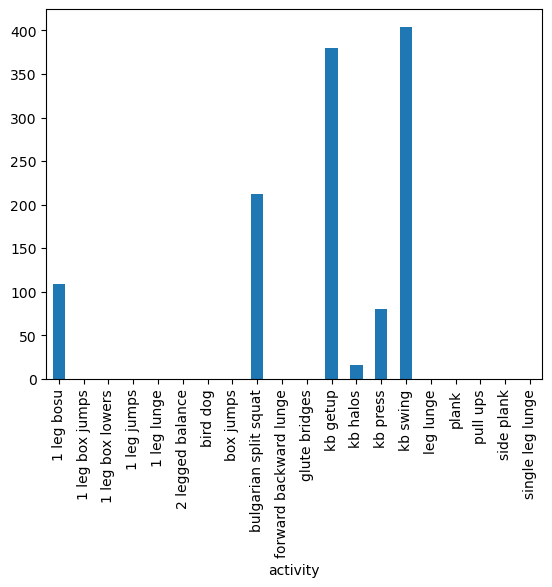

In [46]:
other_df.groupby("activity")['mass (kg)'].sum().plot(kind='bar')

<Axes: xlabel='exercise'>

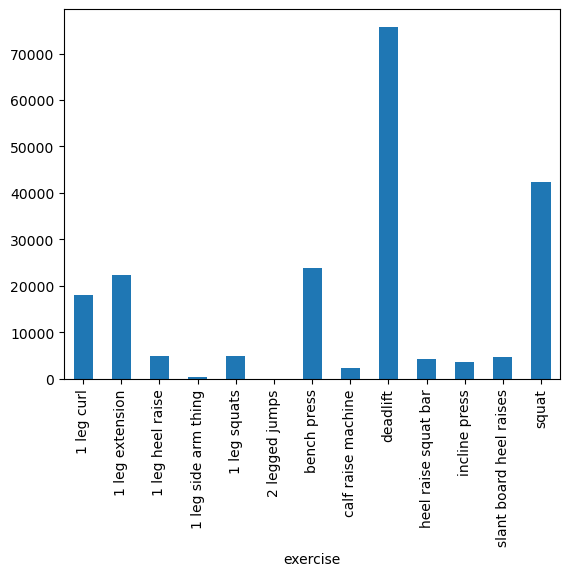

In [49]:
temp_df['total_weight'] = temp_df['reps'] * temp_df['set'] * temp_df['mass (lbs)']
temp_df.groupby('exercise')['total_weight'].sum().plot(kind='bar')

In [51]:
temp_df.groupby('exercise')['mass (lbs)'].max().sort_values()

exercise
2 legged jumps               0
1 leg side arm thing        10
1 leg heel raise            30
incline press               55
slant board heel raises     65
1 leg curl                  85
1 leg squats                85
1 leg extension            115
calf raise machine         115
bench press                135
heel raise squat bar       155
squat                      195
deadlift                   253
Name: mass (lbs), dtype: int64

In [54]:
temp_df.loc[(temp_df['exercise'] == 'calf raise machine') & (temp_df['mass (lbs)'] == 115), 'mass (lbs)'] = 15

In [55]:
temp_df[(temp_df['exercise'] == 'calf raise machine')]

,date,exercise,reps,set,mass (lbs),mass (kgs),rest,notes,to failure?,clean_date,total_weight
0,25.8.15,calf raise machine,10,3,0,0.0,60.0,60/40 2 legged,yes,2025-08-15,0
4,25.8.22,calf raise machine,10,3,0,0.0,60.0,70/30 2 legged,yes,2025-08-22,0
10,25.8.30,calf raise machine,10,3,0,0.0,60.0,single legged!!!,yes,2025-08-30,0
31,25.09.03,calf raise machine,10,5,0,0.0,60.0,NaN,yes,2025-09-03,0
37,25.09.06,calf raise machine,10,3,0,0.0,70.0,need help with other leg,yes,2025-09-06,0
78,25.11.11,calf raise machine,8,1,15,52.0,90.0,NaN,NaN,2025-11-11,920
208,26.02.07,calf raise machine,12,5,10,5.0,90.0,NaN,NaN,2026-02-07,600
217,26.02.16,calf raise machine,15,2,10,NaN,NaN,NaN,NaN,2026-02-16,300
246,26.03.20,calf raise machine,12,3,15,NaN,60.0,NaN,NaN,2026-03-20,540
